In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import gym
import d4rl
import argparse
import pickle
import sys
import tqdm
import importlib
import os
from matplotlib import pyplot as plt

from common.normalizer import StandardNormalizer
# sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath(__file__))))
from common.normalizer import StandardNormalizer
from common import util
from models.transition_model import TransitionModel
from models.d4rl_transition_world_model import D4RLWorldModel
from common.buffer import ReplayBuffer
from common.functional import dict_batch_generator
from scoring import crps_evaluation



No module named 'flow'
/home/ubuntu/miniconda3/envs/mopo/lib/python3.8/site-packages/glfw/__init__.py:917: GLFWError: (65550) b'X11: The DISPLAY environment variable is missing'
  warnings.warn(message, GLFWError)
No module named 'carla'
pybullet build time: Jan 29 2025 23:19:57


RuntimeError: module compiled against API version 0x10 but this version of numpy is 0xe . Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem .

numpy.core.multiarray failed to import


In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# data_path = "/abiomed/intermediate_data_d4rl/hopper-expert-v0_noisy_0.05_unnorm.pkl"
data_path = ""
env_name = 'hopper-expert-v0'
env = gym.make(env_name)
if data_path == "":
    dataset = d4rl.qlearning_dataset(env)
else:
    print('loading')
    with open(data_path, 'rb') as f:
        dataset = pickle.load(f)
    dataset = {key: torch.tensor(dataset[key], dtype = torch.float32) for key in dataset.keys()}

/home/ubuntu/miniconda3/envs/mopo/lib/python3.8/site-packages/gym/envs/registration.py:505: UserWarning: WARN: The environment hopper-expert-v0 is out of date. You should consider upgrading to version `v2` with the environment ID `hopper-expert-v2`.
  logger.warn(
/home/ubuntu/miniconda3/envs/mopo/lib/python3.8/site-packages/d4rl/gym_mujoco/gym_envs.py:13: UserWarning: This environment is deprecated. Please use the most recent version of this environment.
  offline_env.OfflineEnv.__init__(self, **kwargs)
/home/ubuntu/miniconda3/envs/mopo/lib/python3.8/site-packages/gym/spaces/box.py:78: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


load datafile: 100%|██████████| 5/5 [00:03<00:00,  1.43it/s]


In [3]:
obs_shape = env.observation_space.shape
action_dim = np.prod(env.action_space.shape)   

offline_buffer = ReplayBuffer(
            buffer_size=len(dataset["observations"]),
            obs_shape=obs_shape,
            obs_dtype=np.float32,
            action_dim=action_dim,
            action_dtype=np.float32
        )

offline_buffer.load_dataset(dataset)

In [4]:
transition_params= {
        "model_batch_size": 256,
        "use_weight_decay": True,
        "optimizer_class": "Adam",
        "learning_rate": 0.001,
        "holdout_ratio": 0.2,
        "inc_var_loss": True,
        "model": {
            "hidden_dims": [200, 200, 200, 200],
            "decay_weights": [0.000025, 0.00005, 0.000075, 0.000075, 0.0001],
            "act_fn": "swish",
            "out_act_fn": "identity",
            "num_elite": 5,
            "ensemble_size": 7
        }
}
mopo_params = {
        "max_epoch": 125,
        "rollout_batch_size": 50000,
        "rollout_mini_batch_size": 10000,
        "model_retain_epochs": 1,
        "num_env_steps_per_epoch": 1000,
        "train_model_interval": 250,
        "max_trajectory_length": 1000,
        "eval_interval": 1000,
        "num_eval_trajectories": 10,
        "snapshot_interval": 2000,
        "model_env_ratio": 0.95,
        "max_model_update_epochs_to_improve": 5,
        "max_model_train_iterations": "None",
        'model_batch_size': 256,
        "rollout_batch_size":50000,
        "rollout_mini_batch_size":1000,
        "model_retain_epochs":1,
        "num_env_steps_per_epoch":1000,
        "max_epoch":100000,
        "max_model_update_epochs_to_improve":5,
        "max_model_train_iterations":np.inf,
        "hold_out_ratio":0.1,
    }
params = { **transition_params, **mopo_params }

In [5]:
max_sample_size = offline_buffer.get_size
num_train_data = int(max_sample_size * (1.0 - params["holdout_ratio"]))
env_data = offline_buffer.sample_all()
eval_data = {}
for key in env_data.keys():
    eval_data[key] = env_data[key][num_train_data:]



In [6]:
import torch
import torch.nn as nn

def get_eval(model, D, batch_size=50, wm=None, noisy=None, device="cpu"):
    """
    Runs through D['observations'], D['actions'], D['next_observations'] in batches,
    collects all predictions, and computes the average MSE over all elements.

    Returns:
        predd_tensor:  torch.Tensor of shape (N_total, feature_dim)
        avg_mse:       float (sum of squared errors divided by total number of elements)
    """
    loss_fn = nn.MSELoss(reduction="sum")
    mae_fn = nn.L1Loss(reduction="sum")
    total_batches = len(D["observations"]) // batch_size
    total_loss = 0.0
    total_mae_loss = 0

    total_reward_loss = 0.0
    total_reward_mae_loss = 0
    total_elements = 0
    all_preds = []
    reward_preds = []

    for batch_idx in range(total_batches):
        # 1) Slice and convert to torch.Tensor of the right dtype/device
        state_np = D["observations"][batch_idx * batch_size : (batch_idx + 1) * batch_size]
        action_np = D["actions"][batch_idx * batch_size : (batch_idx + 1) * batch_size]
        target_np = D["next_observations"][batch_idx * batch_size : (batch_idx + 1) * batch_size]
        reward_np = D["rewards"][batch_idx * batch_size : (batch_idx + 1) * batch_size]

        target_t = torch.from_numpy(target_np).float().to(device)    # shape: (batch_size, ...)
        reward_t = torch.from_numpy(reward_np).float().to(device)  # shape: (batch_size, ...)


        # 2) Get model predictions
        if wm is None:
            pred_np, _, _, _ = model.predict(state_np, action_np, deterministic=True)
        else:
            pred_np, reward_pred, _ , _ = model.predict(state_np, action_np)

        # Convert prediction to torch.Tensor
        pred_t = torch.from_numpy(pred_np).float().to(device)  # shape: (batch_size, ...)
        pred_reward_t = torch.from_numpy(reward_pred).float().to(device)  # shape: (batch_size, ...)

        # 3) Compute and accumulate MSE (sum over this batch)
        batch_loss = loss_fn(pred_t, target_t).item()         # sum of squared errors for this batch
        total_loss += batch_loss
        total_mae_loss += mae_fn(pred_t, target_t).item()  # sum of absolute errors for this batch
        total_elements += pred_t.numel()
        total_reward_loss += loss_fn(pred_reward_t, reward_t).item()  # reward loss
        total_reward_mae_loss += mae_fn(pred_reward_t, reward_t).item()
        # 4) Store predictions for later concatenation
        all_preds.append(pred_t.detach().cpu())
        reward_preds.append(pred_reward_t.detach().cpu())

    # If there are leftover samples beyond total_batches * batch_size:
    num_left = len(D["observations"]) - total_batches * batch_size
    if num_left > 0:
        start = total_batches * batch_size
        state_np  = D["observations"][start : start + num_left]
        action_np = D["actions"][start : start + num_left]
        target_np = D["next_observations"][start : start + num_left]
        reward_np = D["rewards"][start : start + num_left]

        state_t  = torch.from_numpy(state_np).float().to(device)
        action_t = torch.from_numpy(action_np).float().to(device)
        target_t = torch.from_numpy(target_np).float().to(device)
        reward_t = torch.from_numpy(reward_np).float().to(device)

        if wm is None:
            pred_np, _, _, _ = model.predict(state_np, action_np, deterministic=True)
        else:
            pred_np, reward_pred, _, _ = model.predict(state_np, action_np)

        pred_t = torch.from_numpy(pred_np).float().to(device)
        pred_reward_t = torch.from_numpy(reward_pred).float().to(device)

        batch_loss = loss_fn(pred_t, target_t).item()
        total_loss += batch_loss
        total_mae_loss += mae_fn(pred_t, target_t).item()
        total_elements += pred_t.numel()
        total_reward_loss += loss_fn(pred_reward_t, reward_t).item()
        total_reward_mae_loss += mae_fn(pred_reward_t, reward_t).item()

        
        all_preds.append(pred_t.detach().cpu())
        reward_preds.append(pred_reward_t.detach().cpu())

    # 5) Concatenate all predictions along the first dimension
    if len(all_preds) > 0:
        predd_tensor = torch.cat(all_preds, dim=0)   # shape: (N_total, feature_dim)
        reward_preds_tensor = torch.cat(reward_preds, dim=0)
    else:
        predd_tensor = torch.empty((0,), dtype=torch.float32)
        reward_preds_tensor = torch.empty((0,), dtype=torch.float32)

    # 6) Compute average MSE over all elements
    avg_mse = total_loss / total_elements if total_elements > 0 else float("nan")
    avg_reward_mse = total_reward_loss / total_elements if total_elements > 0 else float("nan")
    avg_mae = total_mae_loss / total_elements if total_elements > 0 else float("nan")
    avg_reward_mae = total_reward_mae_loss / total_elements if total_elements > 0 else float("nan")
    # print(f"Processed {total_batches} full batches"
    #       + (f" + 1 partial batch of {num_left} samples." if num_left > 0 else "."))
    # print(f"— Total elements evaluated: {total_elements}")
    print(f"— Average MSE over all elements: {avg_mse:.6f}")
    print(f"— Average reward MSE over all elements: {avg_reward_mse:.6f}")
    print(f"— Average MAE over all elements: {avg_mae:.6f}")
    print(f"— Average reward MAE over all elements: {avg_reward_mae:.6f}")

    return predd_tensor, reward_preds_tensor


In [7]:
def plot_features(data_noisy, data, title = ''):
    #plot histograms of all features in data
    num_features = data.shape[1]
    num_rows = int(np.ceil(num_features / 3))
    fig, axs = plt.subplots(num_rows, 3, figsize=(15, num_rows * 3))
    axs = axs.flatten()
    for i in range(num_features):
        axs[i].hist(data_noisy[:, i], bins=100, alpha=0.7, color='orange', label ="pred")
        axs[i].hist(data[:, i], bins=100, alpha=0.7, color='blue', label = "ground truth")
        
        axs[i].set_title(f'Feature {i}')
        axs[i].set_xlabel('Value')
        axs[i].set_ylabel('Frequency')
        axs[i].legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [8]:
env_name = 'hopper-expert-v0'
world_model = D4RLWorldModel(env_name)
world_model.load_model(f'saved_models/hopper-expert-v0_noisy/transition_world_model_v2_0.00_0.0.pth')

load datafile:   0%|          | 0/5 [00:00<?, ?it/s]

load datafile: 100%|██████████| 5/5 [00:00<00:00, 13.19it/s]


loaded dataset
Using device: cuda:0


/home/ubuntu/mbpo_uq/models/d4rl_transition_world_model.py:282: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=f'{self.device}')


In [9]:
pred_np, reward_pred, _, stds = world_model.predict(dataset["observations"], dataset["actions"], uq =True)

In [17]:
all_stds = stds[0]
base_rewards = stds[1]
all_stds.shape

torch.Size([999034, 1])

In [13]:
pred_np.shape, reward_pred.shape

((999034, 11), (999034, 1))

In [10]:
batch_size  = 50

total_batches = len(dataset["observations"]) // batch_size
total_loss = 0.0
total_mae_loss = 0

total_reward_loss = 0.0
total_reward_mae_loss = 0
total_elements = 0
all_preds = []
reward_preds = []
all_stds = []
base_rewards = []
for batch_idx in range(total_batches):
    # 1) Slice and convert to torch.Tensor of the right dtype/device
    state_np = dataset["observations"][batch_idx * batch_size : (batch_idx + 1) * batch_size]
    action_np = dataset["actions"][batch_idx * batch_size : (batch_idx + 1) * batch_size]
    target_np = dataset["next_observations"][batch_idx * batch_size : (batch_idx + 1) * batch_size]
    reward_np = dataset["rewards"][batch_idx * batch_size : (batch_idx + 1) * batch_size]

    target_t = torch.from_numpy(target_np).float().to(device)    # shape: (batch_size, ...)
    reward_t = torch.from_numpy(reward_np).float().to(device)  # shape: (batch_size, ...)
    pred_np, reward_pred, _, stds = world_model.predict(state_np, action_np,uq =True)
    all_stds.append(stds[1])
    base_rewards.append(stds[0])
    
    



next_reward torch.Size([50])
torch.Size([50, 11])
batch_stds_max shape:  torch.Size([50, 1])
torch.Size([50, 1])
next_reward torch.Size([50])
torch.Size([50, 11])
batch_stds_max shape:  torch.Size([50, 1])
torch.Size([50, 1])
next_reward torch.Size([50])
torch.Size([50, 11])
batch_stds_max shape:  torch.Size([50, 1])
torch.Size([50, 1])
next_reward torch.Size([50])
torch.Size([50, 11])
batch_stds_max shape:  torch.Size([50, 1])
torch.Size([50, 1])
next_reward torch.Size([50])
torch.Size([50, 11])
batch_stds_max shape:  torch.Size([50, 1])
torch.Size([50, 1])
next_reward torch.Size([50])
torch.Size([50, 11])
batch_stds_max shape:  torch.Size([50, 1])
torch.Size([50, 1])
next_reward torch.Size([50])
torch.Size([50, 11])
batch_stds_max shape:  torch.Size([50, 1])
torch.Size([50, 1])
next_reward torch.Size([50])
torch.Size([50, 11])
batch_stds_max shape:  torch.Size([50, 1])
torch.Size([50, 1])
next_reward torch.Size([50])
torch.Size([50, 11])
batch_stds_max shape:  torch.Size([50, 1])
tor

torch.Size([50, 11])
batch_stds_max shape:  torch.Size([50, 1])
torch.Size([50, 1])
next_reward torch.Size([50])
torch.Size([50, 11])
batch_stds_max shape:  torch.Size([50, 1])
torch.Size([50, 1])
next_reward torch.Size([50])
torch.Size([50, 11])
batch_stds_max shape:  torch.Size([50, 1])
torch.Size([50, 1])
next_reward torch.Size([50])
torch.Size([50, 11])
batch_stds_max shape:  torch.Size([50, 1])
torch.Size([50, 1])
next_reward torch.Size([50])
torch.Size([50, 11])
batch_stds_max shape:  torch.Size([50, 1])
torch.Size([50, 1])
next_reward torch.Size([50])
torch.Size([50, 11])
batch_stds_max shape:  torch.Size([50, 1])
torch.Size([50, 1])
next_reward torch.Size([50])
torch.Size([50, 11])
batch_stds_max shape:  torch.Size([50, 1])
torch.Size([50, 1])
next_reward torch.Size([50])
torch.Size([50, 11])
batch_stds_max shape:  torch.Size([50, 1])
torch.Size([50, 1])
next_reward torch.Size([50])
torch.Size([50, 11])
batch_stds_max shape:  torch.Size([50, 1])
torch.Size([50, 1])
next_reward 

In [21]:
all_stds.shape

torch.Size([34, 1])

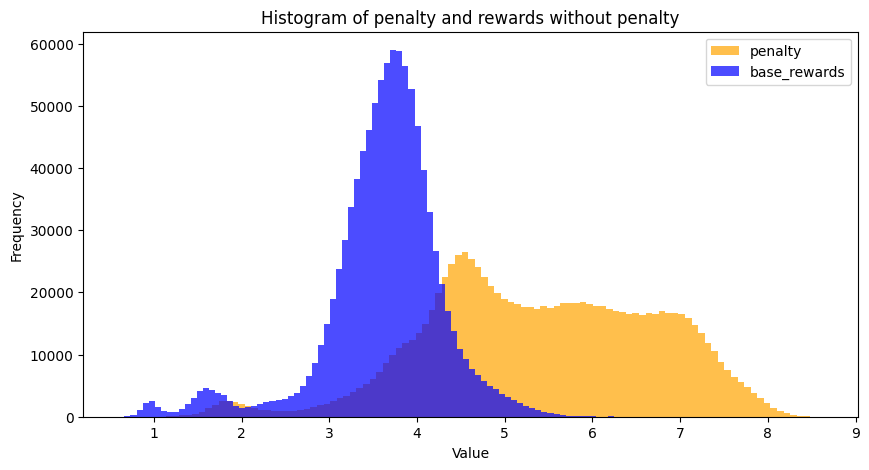

In [18]:
#plot hist of att_stds and base_rewards

# all_stds = torch.cat(all_stds.detach().cpu(), dim=0).detach().cpu().numpy()
# base_rewards = torch.cat(base_rewards.detach().cpu(), dim=0).detach().cpu().numpy()
plt.figure(figsize=(10, 5))
plt.hist(all_stds.detach().cpu().numpy(), bins=100, alpha=0.7, color='orange', label='penalty')
plt.hist(base_rewards.detach().cpu().numpy(), bins=100, alpha=0.7, color='blue', label='base_rewards')
plt.title('Histogram of penalty and rewards without penalty')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

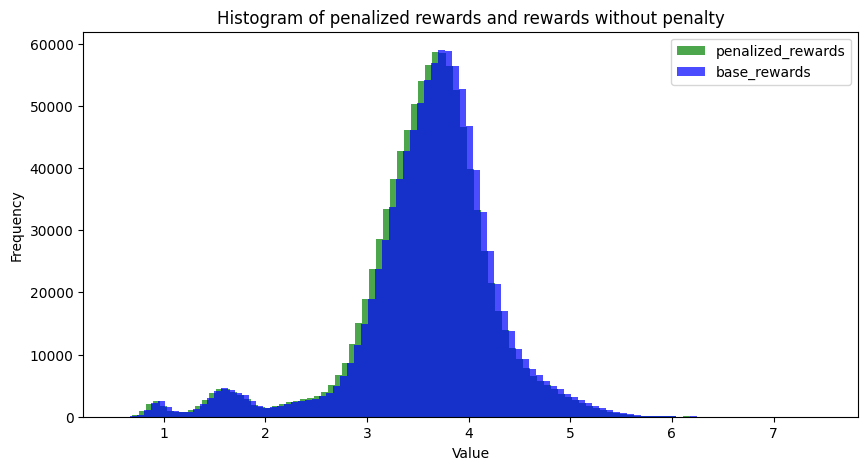

In [14]:
penalized_rewards = base_rewards.reshape(-1,1) - 0.01* all_stds.reshape(-1,1)
#plot penalized rewards
plt.figure(figsize=(10, 5))
plt.hist(penalized_rewards.detach().cpu().numpy(), bins=100, alpha=0.7, color='green', label='penalized_rewards')
plt.hist(base_rewards.detach().cpu().numpy(), bins=100, alpha=0.7, color='blue', label='base_rewards')
plt.title('Histogram of penalized rewards and rewards without penalty')
plt.xlabel('Value')

plt.ylabel('Frequency')
plt.legend()
plt.show()

— Average MSE over all elements: 0.000854
— Average reward MSE over all elements: 0.000008
— Average MAE over all elements: 0.010598
— Average reward MAE over all elements: 0.000429


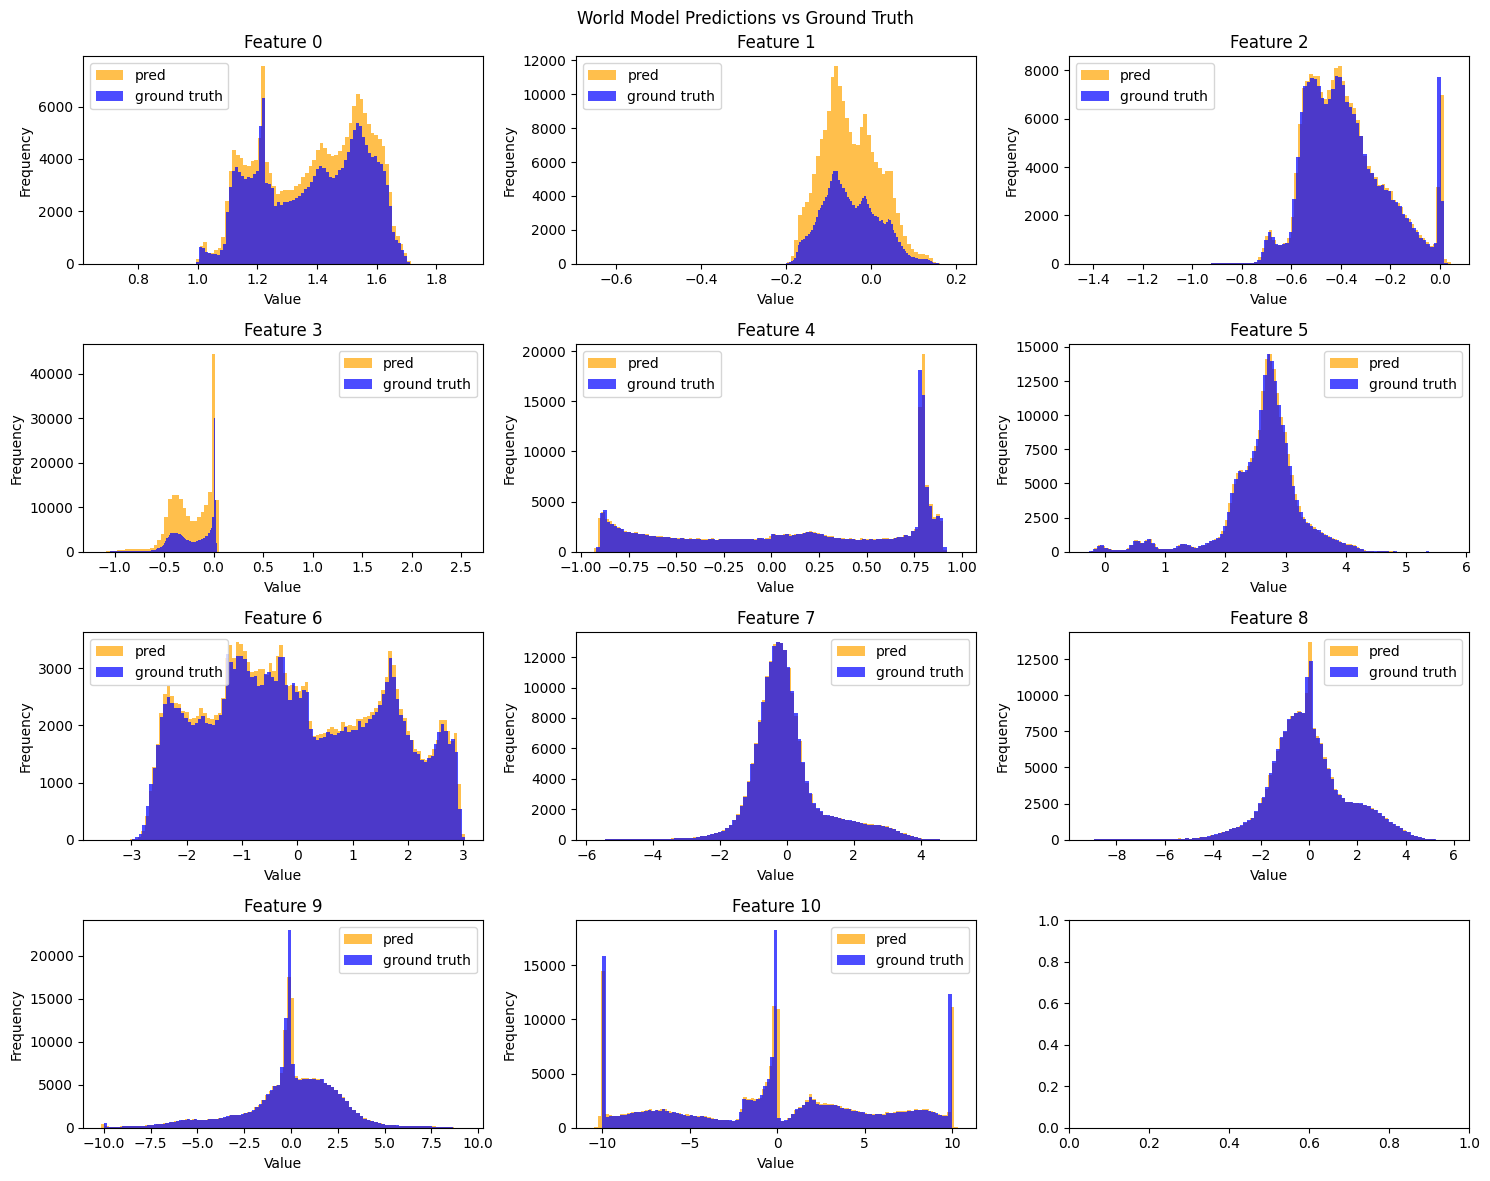

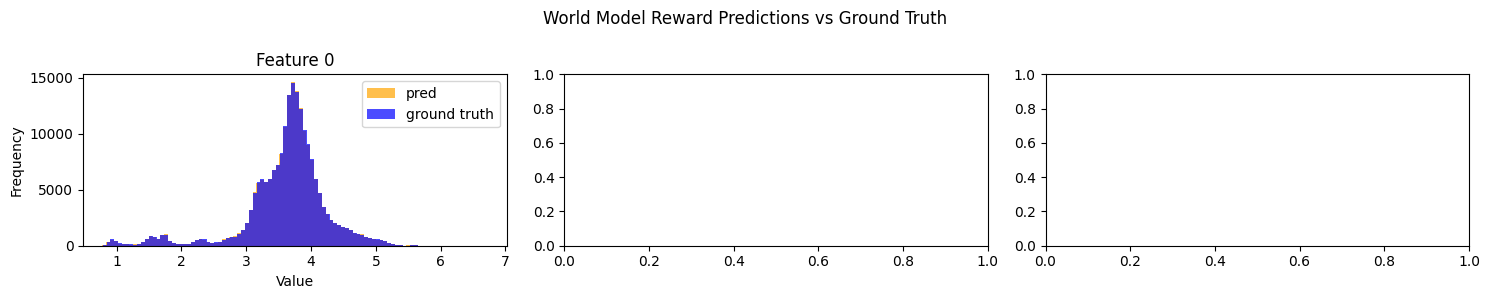

In [20]:

pred, pred_reward =  get_eval(world_model, eval_data, wm=True)
plot_features(pred, eval_data['next_observations'], title='World Model Predictions vs Ground Truth')
plot_features(pred_reward, eval_data['rewards'], title='World Model Reward Predictions vs Ground Truth')
